# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Mu'azah Al'Adawiyah
- **Email:** lunaalister6@gmail.com
- **ID Dicoding:** A429XBF292

## Menentukan Pertanyaan Bisnis

- Berdasarkan kategori produk, produk apa yang penjualannya tertinggi?
- Berdasarkan wilayah mana yang memiliki pelanggan terbanyak dan Metode pembayaran yang sering digunakan pelanggan?
- Bagaimana tingkat kepuasan pelanggan terhadap produk/pelayanan yang diberikan?

## Import Semua Packages/Library yang Digunakan

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from unidecode import unidecode

## Data Wrangling

### Gathering Data

In [29]:
import pandas as pd

# Membaca dataset
geolocation_df = pd.read_csv("dataset/geolocation_dataset.csv")
customers_df = pd.read_csv("dataset/customers_dataset.csv")
orders_df = pd.read_csv("dataset/orders_dataset.csv")
items_df = pd.read_csv("dataset/order_items_dataset.csv")
payments_df = pd.read_csv("dataset/order_payments_dataset.csv")
reviews_df = pd.read_csv("dataset/order_reviews_dataset.csv")
products_df = pd.read_csv("dataset/products_dataset.csv")
category_df = pd.read_csv("dataset/product_category_name_translation.csv")
sellers_df = pd.read_csv("dataset/sellers_dataset.csv")

# Menampilkan Judul pada Tabel
print("=== TABEL GEOLOCATION ===")
display(geolocation_df.head())
print("\n=== TABEL CUSTOMERS ===")
display(customers_df.head())
print("\n=== TABEL ORDERS ===")
display(orders_df.head())
print("\n=== TABEL ITEMS ORDER ===")
display(items_df.head())
print("\n=== TABEL PAYMENTS ORDER ===")
display(payments_df.head())
print("\n=== TABEL REVIEWS ORDER ===")
display(reviews_df.head())
print("\n=== TABEL PRODUCTS ===")
display(products_df.head())
print("\n=== TABEL CATEGORY PRODUCTS ===")
display(category_df.head())
print("\n=== TABEL SELLERS ===")
display(sellers_df.head())

=== TABEL GEOLOCATION ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_city,geolocation_state,geolocation_lat,geolocation_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,14409,franca,SP,-20.502307,-47.396740
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,9790,sao bernardo do campo,SP,-23.730435,-46.541474
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,1151,sao paulo,SP,-23.531294,-46.656980
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,8775,mogi das cruzes,SP,-23.499025,-46.183436
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,13056,campinas,SP,-22.974331,-47.142173



=== TABEL CUSTOMERS ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



=== TABEL ORDERS ===


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



=== TABEL CATEGORY PRODUCTS ===


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



=== TABEL SELLERS ===


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Semua dataset yang dibutuhkan sudah ada
- Memastikan data yang tersedia dapat diakses
- Melihat ada kolom yang hilang atau tidak lengkap

### Assessing Data

In [30]:
# Menampilkan Informasi Tabel
print("=== TABEL GEOLOCATION ===")
geolocation_df.info()
print("\n=== TABEL CUSTOMERS===")
customers_df.info()
print("\n=== TABEL ORDERS ===")
orders_df.info()
print("\n=== TABEL ITEMS ORDER ===")
items_df.info()
print("\n=== TABEL PAYMENTS ORDER ===")
payments_df.info()
print("\n=== TABEL REVIEWS ORDER ===")
reviews_df.info()
print("\n=== TABEL PRODUCTS ===")
products_df.info()
print("\n=== TABEL CATEGORY PRODUCTS ===")
category_df.info()
print("\n=== TABEL SELLERS ===")
sellers_df.info()

=== TABEL GEOLOCATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102783 entries, 0 to 102782
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   customer_id                  102783 non-null  object 
 1   customer_unique_id           102783 non-null  object 
 2   customer_zip_code_prefix     102783 non-null  int64  
 3   customer_city                102783 non-null  object 
 4   customer_state               102783 non-null  object 
 5   geolocation_zip_code_prefix  102783 non-null  int64  
 6   geolocation_city             102783 non-null  object 
 7   geolocation_state            102783 non-null  object 
 8   geolocation_lat              102783 non-null  float64
 9   geolocation_lng              102783 non-null  float64
dtypes: float64(2), int64(2), object(6)
memory usage: 7.8+ MB

=== TABEL CUSTOMERS===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to

In [31]:
# Menampilkan Missing Values / data null
print("=== Missing Values TABEL GEOLOCATION ===\n", geolocation_df.isna().sum())
print("\n=== Missing Values TABEL CUSTOMERS===\n", customers_df.isna().sum())
print("\n=== Missing Values TABEL ORDERS ===\n", orders_df.isna().sum())
print("\n=== Missing Values TABEL ITEMS ORDER ===\n", items_df.isna().sum())
print("\n=== Missing Values TABEL PAYMENTS ORDER ===\n", payments_df.isna().sum())
print("\n=== Missing Values TABEL REVIEWS ORDER ===\n", reviews_df.isna().sum())
print("\n=== Missing Values TABEL PRODUCTS ===\n", products_df.isna().sum())
print("\n=== Missing Values TABEL CATEGORY PRODUCTS ===\n", category_df.isna().sum())
print("\n=== Missing Values TABEL SELLERS ===\n", sellers_df.isna().sum())

=== Missing Values TABEL GEOLOCATION ===
 customer_id                    0
customer_unique_id             0
customer_zip_code_prefix       0
customer_city                  0
customer_state                 0
geolocation_zip_code_prefix    0
geolocation_city               0
geolocation_state              0
geolocation_lat                0
geolocation_lng                0
dtype: int64

=== Missing Values TABEL CUSTOMERS===
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

=== Missing Values TABEL ORDERS ===
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== Missing Values TABEL ITEMS ORDER ===
 order_id      

In [32]:
# Menampilkan Duplikasi Data
print(f"Jumlah Duplikasi Data pada TABEL GEOLOCATION       : {geolocation_df.duplicated().sum()}")
print(f"Jumlah Duplikasi Data pada TABEL CUSTOMERS         : {customers_df.duplicated().sum()}")
print(f"Jumlah Duplikasi Data pada TABEL ORDERS            : {orders_df.duplicated().sum()}")
print(f"Jumlah Duplikasi Data pada TABEL ITEMS ORDER       : {items_df.duplicated().sum()}")
print(f"Jumlah Duplikasi Data pada TABEL PAYMENTS ORDER    : {payments_df.duplicated().sum()}")
print(f"Jumlah Duplikasi Data pada TABEL REVIEWS ORDER     : {reviews_df.duplicated().sum()}")
print(f"Jumlah Duplikasi Data pada TABEL PRODUCTS          : {products_df.duplicated().sum()}")
print(f"Jumlah Duplikasi Data pada TABEL CATEGORY PRODUCTS : {category_df.duplicated().sum()}")
print(f"Jumlah Duplikasi Data pada TABEL SELLERS           : {sellers_df.duplicated().sum()}")

Jumlah Duplikasi Data pada TABEL GEOLOCATION       : 0
Jumlah Duplikasi Data pada TABEL CUSTOMERS         : 0
Jumlah Duplikasi Data pada TABEL ORDERS            : 0
Jumlah Duplikasi Data pada TABEL ITEMS ORDER       : 0
Jumlah Duplikasi Data pada TABEL PAYMENTS ORDER    : 0
Jumlah Duplikasi Data pada TABEL REVIEWS ORDER     : 0
Jumlah Duplikasi Data pada TABEL PRODUCTS          : 0
Jumlah Duplikasi Data pada TABEL CATEGORY PRODUCTS : 0
Jumlah Duplikasi Data pada TABEL SELLERS           : 0


In [33]:
# Menampilkan Describe Pada Tabel
print("=== Describe TABEL GEOLOCATION ===\n", geolocation_df.describe())
print("\n=== Describe TABEL CUSTOMERS===\n", customers_df.describe())
print("\n=== Describe TABEL ORDERS ===\n", orders_df.describe())
print("\n=== Describe TABEL ITEMS ORDER ===\n", items_df.describe())
print("\n=== Describe TABEL PAYMENTS ORDER ===\n", payments_df.describe())
print("\n=== Describe TABEL REVIEWS ORDER ===\n", reviews_df.describe())
print("\n=== Describe TABEL PRODUCTS ===\n", products_df.describe())
print("\n=== Describe TABEL CATEGORY PRODUCTS ===\n", category_df.describe())
print("\n=== Describe TABEL SELLERS ===\n", sellers_df.describe())

=== Describe TABEL GEOLOCATION ===
        customer_zip_code_prefix  geolocation_zip_code_prefix  geolocation_lat  \
count             102783.000000                102783.000000    102783.000000   
mean               35327.313067                 35327.313067       -21.144170   
std                29789.115808                 29789.115808         5.603121   
min                 1003.000000                  1003.000000       -33.690729   
25%                11462.000000                 11462.000000       -23.586700   
50%                24744.000000                 24744.000000       -22.918211   
75%                59610.000000                 59610.000000       -20.002018   
max                99990.000000                 99990.000000        45.065933   

       geolocation_lng  
count    102783.000000  
mean        -46.186609  
std           4.055998  
min         -72.670621  
25%         -48.064192  
50%         -46.637222  
75%         -43.643660  
max           9.341528  

=== Desc

**Insight:**
- Struktur data : Mengetahui format sesuai dengan datetime
- Missing values : Melihat nilai kosong atau Nan
- Duplikasi data : Melihat apakah ada entri yang berulang

### Cleaning Data

Menghapus data duplicates

In [34]:
geolocation_df = geolocation_df.drop_duplicates()

print("Jumlah duplikasi setelah pembersihan:", geolocation_df.duplicated().sum())

Jumlah duplikasi setelah pembersihan: 0


Cleaning Data Null

In [35]:
reviews_df.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

mengubah nilai column review_comment_title & review_comment_message yang memiliki null value dengan default string "No Tittle" & "No Message"

In [38]:
reviews_df["review_comment_title"].fillna("No Title", inplace=True)
reviews_df["review_comment_message"].fillna("No Message", inplace=True)

In [37]:
reviews_df.isna().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [39]:
orders_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [40]:
orders_df = pd.read_csv('dataset/orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
])

print(orders_df.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06 2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39 2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15

In [41]:
orders_df['order_approved_at'] = orders_df['order_approved_at'].fillna(orders_df['order_purchase_timestamp'])
orders_df['order_delivered_customer_date'] = orders_df['order_delivered_customer_date'].fillna(orders_df['order_estimated_delivery_date'])
orders_df["order_delivered_customer_date"] = pd.to_datetime(orders_df["order_delivered_customer_date"])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_carrier_date'] = orders_df['order_delivered_carrier_date'].fillna(pd.Timestamp('1970-01-01'))

print(orders_df.isna().sum())

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64


In [42]:
products_df = pd.read_csv("dataset/products_dataset.csv")
print(products_df.head())

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0       

In [43]:
products_df['product_category_name'] = products_df['product_category_name'].fillna("Unknown")
for col in ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']:
    mode_value = products_df[col].mode()[0]
    products_df[col] = products_df[col].fillna(mode_value)
for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    median_value = products_df[col].median()
    products_df[col] = products_df[col].fillna(median_value)

print(products_df.isna().sum())

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


**Insight:**
- Terjadinya duplikasi pada data geolokasi sebanyak 261831, yang memungkinkan karena satu tempat memiliki lebih dari satu entri.
- Missing values ditemukan di beberapa kolom, seperti tanggal pengiriman, review pesanan, dan produk.
- Beberapa kolom perlu diformat ulang, seperti kolom tanggal yang awalnya berupa string.

## Exploratory Data Analysis (EDA)

### Explore Customers_df

In [22]:
customers_df.sample(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
40248,84bc567e9c0441681bb72fe00357f22e,0964c7f23dd25a5c1b4587b1dd71d2d3,71741,brasilia,DF
25850,c75ec7b2a6db11bab5c351449b506192,3960b922a01a7713c17b532475a0266b,88220,itapema,SC
75948,eb562fef11da58b078feead2bfc91b47,06220b4bd98044def9ac913508f523d8,15806,catanduva,SP
29084,309239af9998f640f8572abd96482709,b9fc2d4c90bdadc7052fabe8353084ed,75709,catalao,GO
80155,29d53b94d4f30c11a33b9555ce6a9639,7b36f0eea1ec45d1930553b751265c58,31744,belo horizonte,MG
83601,16738db2ba964d2b05d642b0ff222451,1d59e4eecfa206d206db45c317e78920,35600,bom despacho,MG
50301,58178a46a84b4313b9a859185a228113,f1844513d950400294c26e9b0056b238,34007,nova lima,MG
32282,59b5afd367220e7d7e8b23cf010e44c7,7ef6d1de203a99ee62a7d14e5329668d,76824,porto velho,RO
33942,43828af3e880066850c0cf0fc0f5e56a,a7d4cb9ba936ebc0eb30b73c5d3a62d8,92025,canoas,RS
53758,ba0cb3c8fdd57a9f03fe71f48986dd8c,e1e31ea94bc398a8158ff5e7724fb645,9626,sao bernardo do campo,SP


In [4]:
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


mengetahui asal kota customer yang terbanyak

In [45]:
customers_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

customer_city
sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
brasilia           2131
curitiba           1521
                  ...  
ibiara                1
rio espera            1
rio dos indios        1
rio dos cedros        1
lagoao                1
Name: customer_id, Length: 4119, dtype: int64

In [49]:
customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: customer_id, dtype: int64

In [55]:
customer_id_in_orders_df =  orders_df.customer_id.tolist()
customers_df["status"] = customers_df["customer_id"].apply(lambda x: "Active" if x in customer_id_in_orders_df else "Non Active")
customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status
90380,117436669e184f4609199f7301fe4cd8,3019ee74ba656d872ff6dda2de845cd7,1224,sao paulo,SP,Active
53499,403e3939144e4e8f0d0bece178186f2a,63af55307fe5360d1005f03999b261e7,12704,cruzeiro,SP,Active
57353,c86e636fca17f603f5d359d94c92b256,7a51d1598e6ee450583ba8a3f7a6454c,27351,barra mansa,RJ,Active
66284,e2777962242ff48994c639668573a8ab,4632e6cd7606a309d6c2c02671dd3b0e,35770,caetanopolis,MG,Active
86407,a53d0a93c43728928e650fa9594d5f61,137bbbdc413c31c44d77c2804c1c90af,31730,belo horizonte,MG,Active


In [57]:
customers_df.groupby(by="status").customer_id.count()

status
Active    99441
Name: customer_id, dtype: int64

### Explore Orders_df

In [58]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
count,99441,99441,99441,99441,99441,99441,99441,99441,99441.000000
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,NaN
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 19:07:21.164720896,2017-02-24 11:40:50.281151744,2018-01-13 06:50:40.982220800,2018-01-24 03:08:37.730111232,322.759667
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,1970-01-01 00:00:00,2016-09-30 00:00:00,2016-09-30 00:00:00,-16.000000
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 21:55:13,2017-09-07 00:22:29,2017-09-22 21:28:06,2017-10-03 00:00:00,4.000000
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:54:30,2018-01-19 21:29:35,2018-02-01 19:34:49,2018-02-15 00:00:00,7.000000
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 23:50:21,2018-05-07 13:30:00,2018-05-15 17:51:03,2018-05-25 00:00:00,13.000000
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-10-17 17:30:18,2018-09-11 19:48:28,2018-11-12 00:00:00,2018-11-12 00:00:00,17847.000000


In [59]:
delivery_time = orders_df["order_delivered_customer_date"] - orders_df["order_delivered_carrier_date"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds())
orders_df["delivery_time"] = round(delivery_time/86400)

In [60]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
34407,7b14b680a9c285d579e2a51495f30173,c68fdd92d5ccd9fcb9af63f50661c9d1,delivered,2017-05-03 19:41:22,2017-05-04 02:50:45,2017-05-04 13:12:11,2017-05-16 12:25:50,2017-05-24,12.0
21333,0c2bbee72e02611ffd7ba4c1b30b7a18,d3a6688ba3e7d1f5775d0ae9b2992712,delivered,2017-11-23 21:49:07,2017-11-23 22:07:55,2017-11-24 21:51:34,2017-12-02 17:13:28,2017-12-07,8.0
8219,87c9a177bd8b6546136bc14128ac1d3b,4f93dc7eaca0dd47d8f458a8d26159f0,delivered,2017-09-29 18:18:59,2017-09-29 18:35:16,2017-10-04 20:35:42,2017-10-09 21:52:31,2017-10-26,5.0
67536,2dea508202fbd39c677502defdef2d21,986eba2f0d54f5b350b50ffe122ec2eb,delivered,2017-07-22 20:19:16,2017-07-22 20:35:18,2017-07-24 13:51:58,2017-07-25 21:58:40,2017-08-11,1.0
43680,3b1c5a036e0412d8c9dda3d6df67782a,0dd70915d5f46c4cf8afce382e0b5b86,delivered,2017-02-23 15:32:21,2017-02-23 21:55:18,2017-03-13 12:09:11,2017-03-18 11:07:36,2017-04-06,5.0


### Merge customers_df & orders_df

In [61]:
orders_customers_df = pd.merge(
    left=customers_df,
    right=orders_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)
orders_customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,Active,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,Active,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,14.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,Active,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,3.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,Active,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,Active,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,10.0


Jumlah order berdasarkan kota

In [62]:
orders_customers_df.groupby(by="customer_city").order_id.nunique().sort_values(ascending=False).reset_index().head(10)

,customer_city,order_id
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938


### Merge products_df & category_df

In [63]:
new_products_df=pd.merge(
    left=products_df,
    right=category_df,
    how='left',
    left_on='product_category_name',
    right_on='product_category_name'
)
new_products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [34]:
new_products_df.groupby(by="product_category_name").product_id.nunique().sort_values(ascending=False).head(10)

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: product_id, dtype: int64

In [64]:
new_products_df.groupby(by="product_category_name_english").product_id.nunique().sort_values(ascending=False).head(10)

product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: product_id, dtype: int64

In [65]:
sellers_df.sample(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
31,e9e446d01bd10a97a8ffcfc4a3a20cb2,2261,sao paulo,SP
1957,58e4b302b54937e55a678c4d15111da4,83402,colombo,PR
295,1cbd50a8c52e6cf8e315c5709fab386f,83830,fazenda rio grande,PR
2482,5795aebfe331fbcd02a2c4b679fb7952,88132,palhoca,SC
1628,4e06067cc08b3f41d837768d392c3ee3,32604,betim,MG


In [66]:
payments_df.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
2666,d2ce9688abb199cda1a106b293847827,1,credit_card,1,37.37
66724,9d817e85739426de1efcd842ee59cbd1,1,credit_card,10,878.04
102067,c20c39bdb12b843034d5b268c984c02a,1,credit_card,3,67.05
60437,44653f1f97b2b55f4f96313c3ac8c5c0,1,credit_card,5,117.94
75388,ab4d0987c77bb6437a463c0b0af774e9,1,credit_card,1,161.86


### Merge Reviews_df & Payments_df

In [68]:
orders_revpayments=pd.merge(
    left=reviews_df,
    right=payments_df,
    how='left',
    left_on='order_id',
    right_on='order_id'
)
orders_revpayments.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Message,2018-01-18 00:00:00,2018-01-18 21:46:59,1.0,credit_card,8.0,397.26
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Message,2018-03-10 00:00:00,2018-03-11 03:05:13,1.0,credit_card,1.0,88.09
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Message,2018-02-17 00:00:00,2018-02-18 14:36:24,1.0,credit_card,1.0,194.12
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,1.0,credit_card,1.0,222.84
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,1.0,credit_card,10.0,1333.25


In [70]:
orders_revpayments.groupby(by="payment_type").agg({
    "order_id": "nunique",
    "payment_value":  ["min", "max"]
})

order_id payment_value          
              nunique           min       max
payment_type                                 
boleto          19636         11.62   7274.88
credit_card     75910          0.01  13664.08
debit_card       1521         13.38   4445.50
not_defined         3          0.00      0.00
voucher          3829          0.00   3184.34

In [71]:
orders_revpayments.groupby(by='payment_type')['order_id'].size().sort_values(ascending=False)

payment_type
credit_card    76600
boleto         19762
voucher         5783
debit_card      1529
not_defined        3
Name: order_id, dtype: int64

### Merge orders_customers & orders_revpayments

In [72]:
customers_df=pd.merge(
    left=orders_customers_df,
    right= orders_revpayments,
    how='left',
    left_on='order_id',
    right_on='order_id'
)
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status,order_id,order_status,order_purchase_timestamp,order_approved_at,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,Active,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,...,88b8b52d46df026a9d1ad2136a59b30b,4.0,No Title,No Message,2017-05-26 00:00:00,2017-05-30 22:34:40,1.0,credit_card,2.0,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,Active,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,...,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,No Title,No Message,2018-01-30 00:00:00,2018-02-10 22:43:29,1.0,credit_card,8.0,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,Active,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,...,5ad6695d76ee186dc473c42706984d87,5.0,No Title,No Message,2018-06-15 00:00:00,2018-06-15 12:10:59,1.0,credit_card,7.0,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,Active,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,...,059a801bb31f6aab2266e672cab87bc5,5.0,No Title,No Message,2018-03-29 00:00:00,2018-04-02 18:36:47,1.0,credit_card,1.0,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,Active,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,...,8490879d58d6c5d7773f2739a03f089a,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52,1.0,credit_card,8.0,252.25


### Merge items_df & sellers_df

In [73]:
product_sellers = pd.merge(
    left=items_df,
    right=sellers_df,
    how="left",
    left_on="seller_id",
    right_on="seller_id"
)
product_sellers.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR


In [74]:
product_sellers.groupby(by="seller_city").seller_id.nunique().sort_values(ascending=False).head(10)

seller_city
sao paulo         694
curitiba          127
rio de janeiro     96
belo horizonte     68
ribeirao preto     52
guarulhos          50
ibitinga           49
santo andre        45
campinas           41
maringa            40
Name: seller_id, dtype: int64

### Merge product_sellers & new_products_df

In [75]:
sellers_df = pd.merge(
    left=new_products_df,
    right=product_sellers,
    how="left",
    left_on="product_id",
    right_on="product_id"
)
sellers_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery,e17e4f88e31525f7deef66779844ddce,1,5670f4db5b62c43d542e1b2d56b0cf7c,2018-04-30 17:33:54,10.91,7.39,3694,sao paulo,SP
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art,5236307716393b7114b53ee991f36956,1,b561927807645834b59ef0d16ba55a24,2018-02-06 19:11:15,248.00,17.99,2955,sao paulo,SP
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure,01f66e58769f84129811d43eefd187fb,1,7b07b3c7487f0ea825fc6df75abd658b,2018-07-11 21:30:20,79.80,7.82,2016,sao paulo,SP
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby,143d00a4f2dde4e0364ee1821577adb3,1,c510bc1718f0f2961eaa42a23330681a,2018-08-07 09:10:13,112.30,9.54,13330,indaiatuba,SP
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares,86cafb8794cb99a9b1b77fc8e48fbbbb,1,0be8ff43f22e456b4e0371b2245e4d01,2018-04-17 01:30:23,37.90,8.29,4461,sao paulo,SP


In [76]:
sellers_df.sort_values(by="price", ascending=False)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
20528,489ae2aa008f021502940f251d4cce7f,utilidades_domesticas,31.0,875.0,2.0,30000.0,60.0,61.0,33.0,housewares,0812eb902a67711a1cb742b3cdaa65ae,1,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.00,194.31,3635,sao paulo,SP
73922,69c590f7ffc7bf8db97190b6cb6ed62e,pcs,50.0,1935.0,4.0,5660.0,54.0,18.0,47.0,computers,fefacc66af859508bf1a7934eab1e97f,1,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.00,193.21,86026,londrina,PR
49503,1bdf5e6731585cf01aa8169c7028d6ad,artes,28.0,3954.0,2.0,7400.0,47.0,25.0,25.0,art,f5136e38d1a14a4dbd87dff67da82701,1,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.00,227.66,74210,goiania,GO
71835,a6492cc69376c469ab6f61d8f44de961,eletroportateis,41.0,1780.0,2.0,22600.0,55.0,40.0,40.0,small_appliances,a96610ab360d42a2e5335a3998b4718a,1,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.00,151.34,13480,limeira,SP
32232,c3ed642d592594bb648ff4a04cee2747,eletroportateis,59.0,2217.0,2.0,30000.0,50.0,49.0,50.0,small_appliances,199af31afc78c699f0dbf71fb178d4d4,1,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.00,74.34,13480,limeira,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55911,05b515fdc76e888aada3c6d66c201dff,beleza_saude,45.0,231.0,3.0,800.0,21.0,4.0,15.0,health_beauty,8272b63d03f5f79c56e9e4120aec44ef,11,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,3813,sao paulo,SP
55903,05b515fdc76e888aada3c6d66c201dff,beleza_saude,45.0,231.0,3.0,800.0,21.0,4.0,15.0,health_beauty,8272b63d03f5f79c56e9e4120aec44ef,3,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89,3813,sao paulo,SP
29610,8a3254bee785a526d548a81a9bc3c9be,construcao_ferramentas_construcao,25.0,1041.0,5.0,200.0,16.0,4.0,11.0,construction_tools_construction,c5bdd8ef3c0ec420232e668302179113,2,96804ea39d96eb908e7c3afdb671bb9e,2018-05-07 02:55:22,0.85,22.30,38950,ibia,MG
29608,8a3254bee785a526d548a81a9bc3c9be,construcao_ferramentas_construcao,25.0,1041.0,5.0,200.0,16.0,4.0,11.0,construction_tools_construction,3ee6513ae7ea23bdfab5b9ab60bffcb5,1,96804ea39d96eb908e7c3afdb671bb9e,2018-05-04 03:55:26,0.85,18.23,38950,ibia,MG


In [46]:
sellers_df.groupby(by="product_category_name_english").agg({
    "order_id": "nunique",
    "price":  ["min", "max"]
})

order_id  price         
                               nunique    min      max
product_category_name_english                         
agro_industry_and_commerce         182  12.99  2990.00
air_conditioning                   253  10.90  1599.00
art                                202   3.50  6499.00
arts_and_craftmanship               23   9.80   289.49
audio                              350  14.90   598.99
...                                ...    ...      ...
stationery                        2311   2.29  1693.00
tablets_printing_image              79  14.90   889.99
telephony                         4199   5.00  2428.00
toys                              3886   4.90  1699.99
watches_gifts                     5624   8.99  3999.90

[71 rows x 3 columns]

### Explore geolocation_df

In [77]:
geolocation_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_city,geolocation_state,geolocation_lat,geolocation_lng
18905,48056f086b5be2b2a1c6d64bcb1821ec,e75777ab515d2750cdc5124052a0dfee,82400,curitiba,PR,82400,curitiba,PR,-25.394166,-49.342270
102117,b9eb6b78f19bc70a6f4cd538aac606c0,461cef89cc7b81f2ba1c0f1216719b8a,15300,general salgado,SP,15300,general salgado,SP,-20.646454,-50.362001
46224,dd14869d16243404d0aec5b90e588634,14967f4bec96864de5c5e2ce63b80bc2,36046,juiz de fora,MG,36046,juiz de fora,MG,-21.731445,-43.359769
93497,136a28c6b13f394abf5eda9cfb6ea934,4c4b5dc90eb4e33188153ca3e7999f92,6380,carapicuiba,SP,6380,carapicuiba,SP,-23.539105,-46.838078
11298,737b1298a317de65d412522aa016f2c2,59702eced274e292fe98816f81f902ad,4280,sao paulo,SP,4280,sao paulo,SP,-23.604340,-46.607023


In [78]:
(geolocation_df['geolocation_city']=='são paulo').sum()

0

In [79]:
geolocation_df['geolocation_city']=geolocation_df['geolocation_city'].apply(lambda x: unidecode(x))

In [80]:
geolocation_df.groupby(by=['geolocation_city','geolocation_state'])['geolocation_zip_code_prefix'].size().sort_values(ascending=False).reset_index()

,geolocation_city,geolocation_state,geolocation_zip_code_prefix
0,sao paulo,SP,15598
1,rio de janeiro,RJ,6904
2,belo horizonte,MG,2789
3,brasilia,DF,1964
4,curitiba,PR,1524
...,...,...,...
4407,fatima,TO,1
4408,faxinalzinho,RS,1
4409,penedo (itatiaia),RJ,1
4410,felicio dos santos,MG,1


In [8]:
(geolocation_df['geolocation_city']=='são paulo').sum()

0

### Explore All Data

### Merge all data

In [81]:
all_data = pd.merge(
    left=customers_df,
    right=sellers_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)
all_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status,order_id,order_status,order_purchase_timestamp,order_approved_at,...,product_width_cm,product_category_name_english,order_item_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,Active,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,...,31.0,office_furniture,1.0,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,8577.0,itaquaquecetuba,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,Active,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,...,40.0,housewares,1.0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,88303.0,itajai,SC
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,Active,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,...,17.0,office_furniture,1.0,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,8577.0,itaquaquecetuba,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,Active,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,...,28.0,office_furniture,1.0,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,8577.0,itaquaquecetuba,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,Active,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,...,35.0,home_confort,1.0,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,14940.0,ibitinga,SP


In [ ]:
all_data.info()

In [ ]:
all_data.groupby(by=["customer_city", "product_category_name_english"]).agg({
    "price": "sum",
    "freight_value": "sum"
})

In [ ]:
all_data.groupby(by=["customer_state", "product_category_name_english"]).agg({
    "price": "sum",
    "freight_value": "sum"
})

In [ ]:
all_data.groupby(by="customer_state").agg({
    "order_id": "nunique",
    "payment_value": "sum"
}).sort_values(by="payment_value", ascending=False)

In [ ]:
all_data.groupby(by="product_category_name_english").agg({
    "order_id": "nunique",
    "review_score":  ["min", "max"]
})

### Convert all_data to .csv

In [60]:
all_data.to_csv('data/all_data.csv', index=False)

**Insight:**
- seller_city tertinggi yaitu sao paulo dan terendah yaitu maringa
- customer_state terendah yaitu RR

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berdasarkan kategori produk, produk apa yang penjualannya tertinggi?

In [86]:
sum_order_items_df = all_data.groupby("product_category_name_english")["product_id"].count().reset_index()
sum_order_items_df = sum_order_items_df.rename(columns={"product_id": "products"})
sum_order_items_df = sum_order_items_df.sort_values(by="products", ascending=False)
sum_order_items_df = sum_order_items_df.head(10)

sum_order_items_df.head()

,product_category_name_english,products
7,bed_bath_table,11980
43,health_beauty,10029
65,sports_leisure,9002
39,furniture_decor,8827
15,computers_accessories,8150


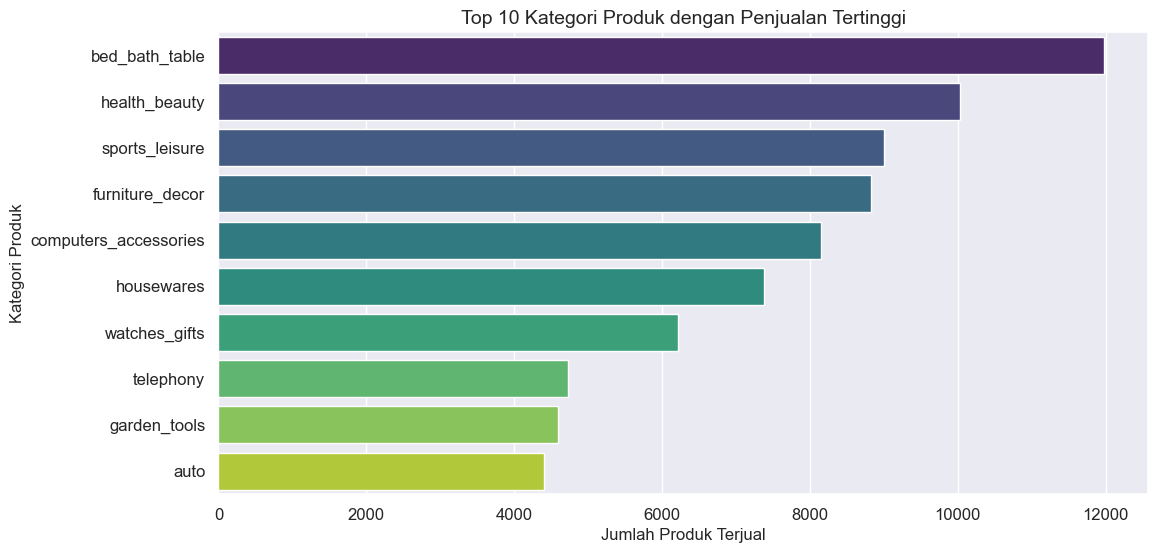

In [88]:
sum_order_items_df = all_data.groupby("product_category_name_english")["product_id"].count().reset_index()
sum_order_items_df = sum_order_items_df.rename(columns={"product_id": "total_sales"})
sum_order_items_df = sum_order_items_df.sort_values(by="total_sales", ascending=False)

top_10_categories = sum_order_items_df.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x="total_sales", y="product_category_name_english", data=top_10_categories, hue="product_category_name_english", palette="viridis", legend=False)

plt.title("Top 10 Kategori Produk dengan Penjualan Tertinggi", fontsize=14)
plt.xlabel("Jumlah Produk Terjual")
plt.ylabel("Kategori Produk")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### Pertanyaan 2: Berdasarkan wilayah mana yang memiliki pelanggan terbanyak dan Metode pembayaran yang sering digunakan pelanggan?

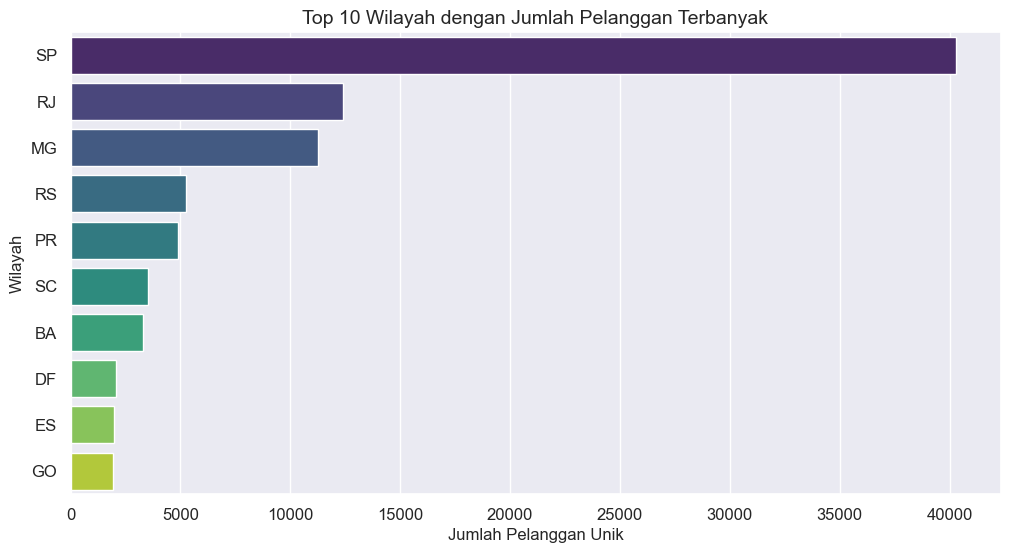

In [93]:
top_regions = all_data.groupby("customer_state")["customer_unique_id"].nunique().reset_index()
top_regions = top_regions.sort_values(by="customer_unique_id", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="customer_unique_id", y="customer_state", data=top_regions.head(10), hue="customer_state", palette="viridis", legend=False)

plt.title("Top 10 Wilayah dengan Jumlah Pelanggan Terbanyak", fontsize=14)
plt.xlabel("Jumlah Pelanggan Unik")
plt.ylabel("Wilayah")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

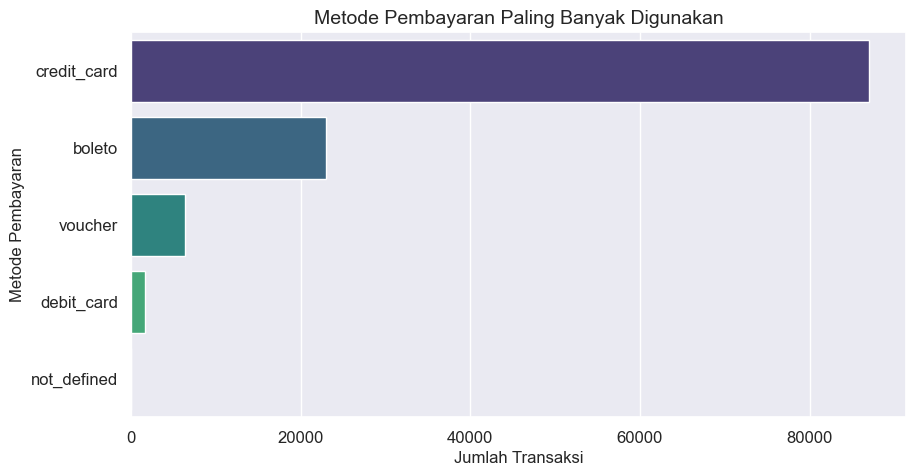

In [97]:
payment_counts = all_data["payment_type"].value_counts().reset_index()
payment_counts.columns = ["payment_type", "total_transactions"]

plt.figure(figsize=(10, 5))
sns.barplot(x="total_transactions", y="payment_type", data=payment_counts, hue="payment_type", palette="viridis", legend=False)

plt.title("Metode Pembayaran Paling Banyak Digunakan", fontsize=14)
plt.xlabel("Jumlah Transaksi")
plt.ylabel("Metode Pembayaran")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### Pertanyaan 3: Bagaimana tingkat kepuasan pelanggan terhadap produk/pelayanan yang diberikan?

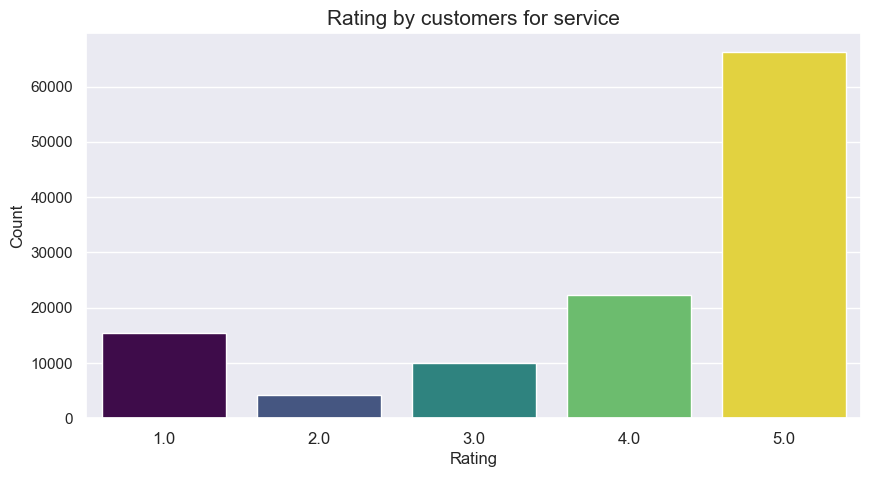

In [64]:
review_scores = all_data['review_score'].value_counts().sort_values(ascending=False)

most_common_score = review_scores.idxmax()

sns.set(style="darkgrid")

plt.figure(figsize=(10, 5))
sns.barplot(x=review_scores.index, y=review_scores.values, hue=review_scores.index, palette="viridis", legend=False)

plt.title("Rating by customers for service", fontsize=15)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(fontsize=12)
plt.show()

**Insight:**
- Produk tertinggi berdasarkan kategori produk ialah Bed_bayh_table.
- Top 10 wilayah dengan jumlah terbanyak yaitu SP, RJ, MG, RS, PR, SC, BA, DF, ES, dan GO
- Dari visualisasi metode pembayaran, metode yang paling sering digunakan adalah kartu kredit, diikuti oleh Boleto (transfer bank) dan debit card.
- Customer sangat puas terhadap pelayanan yang telah diberikan dan meningkatkan lagi untuk menjadi lebih baik.

## Analysis Lanjutan

In [86]:
import datetime as dt

now = dt.datetime(2018, 10, 17)

all_data['order_purchase_timestamp'] = pd.to_datetime(all_data['order_purchase_timestamp'])

# Group by 'customer_id' and calculate Recency, Frequency, and Monetary
recency = (now - all_data.groupby('customer_id')['order_purchase_timestamp'].max()).dt.days
frequency = all_data.groupby('customer_id')['order_id'].count()
monetary = all_data.groupby('customer_id')['price'].sum()

In [87]:
rfm = pd.DataFrame({
    'customer_id': recency.index,
    'Recency': recency.values,
    'Frequency': frequency.values,
    'Monetary': monetary.values
})

# Calculate Percentiles
rfm_percentiles = rfm[['Recency', 'Frequency', 'Monetary']].rank(pct=True)

# RFM Segmentation
rfm['RFM_Score'] = rfm_percentiles['Recency'] * 100 + rfm_percentiles['Frequency'] * 10 + rfm_percentiles['Monetary']
rfm['RFM_Score'] = rfm['RFM_Score'].clip(0, 100)
rfm_segment = pd.cut(rfm['RFM_Score'], bins=[0, 33, 66, 100], labels=['Low', 'Mid', 'High'])
rfm['Segment'] = rfm_segment

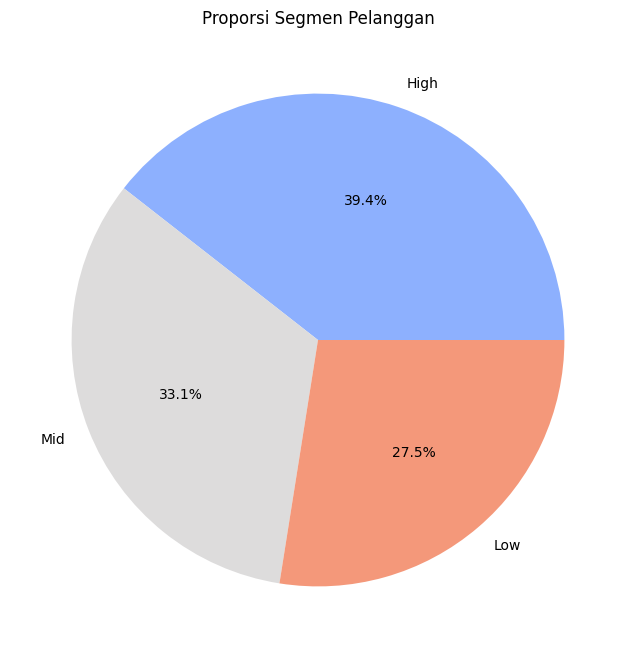

In [94]:
rfm_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(rfm_counts, labels=rfm_counts.index, autopct="%1.1f%%", colors=sns.color_palette("coolwarm", len(rfm_counts)))

plt.title("Proporsi Segmen Pelanggan")
plt.show()

### Insight :

Pie chart ini menunjukkan proporsi setiap segmen pelanggan berdasarkan metode RFM Segmentation (Recency, Frequency, Monetary).

Pie chart menggambarkan proporsi pelanggan berdasarkan tiga kategori utama, yaitu :
- High : Pelanggan yang sering berbelanja, baru saja melakukan pembelian, dan memiliki nilai transaksi tinggi.
- Mid : Pelanggan dengan aktivitas pembelian sedang, masih cukup aktif tetapi tidak seintens High.
- Low : Pelanggan yang jarang atau sudah lama tidak melakukan pembelian.

In [89]:
# Customer dengan pengeluaran terbesar
top_monetary_customers = rfm.sort_values(by='Monetary', ascending=False).head(10)
top_monetary_customers.head()

,customer_id,Recency,Frequency,Monetary,RFM_Score,Segment
8546,1617b1357756262bfa56ab541c47bc16,382,8,13440.00,83.422039,High
60184,9af2372a1e49340278e7c1ef8d749f34,544,29,11383.95,100.000000,High
86603,de832e8dbb1f588a47013e53feaa67cc,505,15,10856.10,99.553243,High
38590,63b964e79dee32a3587651701a2b8dbf,244,24,9888.00,54.976197,Mid
43009,6f241d5bbb142b6f764387c8c270645a,159,7,9520.14,34.261793,Mid


In [90]:
# Customer yang terakhir belanja
recent_customers = rfm.sort_values(by='Recency', ascending=False).head(10)
recent_customers.head()

,customer_id,Recency,Frequency,Monetary,RFM_Score,Segment
3354,08c5351a6aca1c1589a38f244edeee9d,772,2,72.89,100.0,High
40289,683c54fc24d40ee9f8a6fc179fd9856c,771,1,59.50,100.0,High
38013,622e13439d6b5a0b486c435618b2679e,763,1,0.00,100.0,High
52277,86dc2ffce2dfff336de2f386a786e574,761,3,134.97,100.0,High
68946,b106b360fe2ef8849fbbd056f777b4d5,744,1,100.00,100.0,High


Recency: Menunjukkan seberapa lama pelanggan terakhir kali melakukan pembelian. Semakin kecil nilai Recency, semakin baru pelanggan tersebut melakukan pembelian.

Frequency: Menunjukkan seberapa sering pelanggan melakukan pembelian dalam suatu periode waktu tertentu. Nilai Frequency yang tinggi menunjukkan bahwa pelanggan tersebut sering melakukan pembelian.

Monetary: Menunjukkan total nilai pembelian atau pengeluaran yang dilakukan oleh pelanggan. Nilai Monetary yang tinggi menunjukkan bahwa pelanggan tersebut menghabiskan lebih banyak uang.

RFM_Score: Merupakan nilai skor yang dihasilkan dari kombinasi Recency, Frequency, dan Monetary. RFM Score yang tinggi menunjukkan pelanggan yang masih aktif, berbelanja secara teratur, dan memberikan kontribusi signifikan terhadap pendapatan bisnis.

Segment: Segment "High" akan berisi pelanggan yang baru-baru ini sering berbelanja dan menghabiskan banyak uang, sedangkan segment "Low" akan berisi pelanggan yang jarang berbelanja dan menghabiskan sedikit uang. Segment "Mid" berada di tengah-tengah, menunjukkan perilaku yang tidak terlalu ekstrem dalam hal Recency, Frequency, dan Monetary.

## Conclusion

- Berdasarkan kategori produk, produk apa yang penjualannya tertinggi?
  Berdasarkan grafik diatas menjelaskan bahwa penjualan produk paling tinggi berdasarkan kategori produk yaitu bed_bath_table dengan jumlah produk terjual sebanyak 12000. Diikuti oleh health_beauty dan sports_leisure. Untuk penjualan produk Terendah yaitu auto dengan jumlah produk terjual sebanyak 4000.

- Berdasarkan wilayah mana yang memiliki pelanggan terbanyak dan Metode pembayaran yang sering digunakan pelanggan? 
  Wilayah terbanyak memiliki pelanggan yaitu wilayah sp dengan jumlah 40000 dan urutan 3 dari bawah yaitu wilayah DF, ES, dan GO. Dan Metode pembayaran paling populer berdasarkan hasil visualisasi tersebut menunjukkan bahwa umumnya metode seperti credit card atau boleto (di Brasil) lebih sering digunakan.

- Bagaimana tingkat kepuasan pelanggan terhadap produk/pelayanan yang diberikan?
  Berdasarkan grafik diatas menjelaskan bahwa rating pelanggan terhadap pelayanan menunjukkan angka 5 yang memiliki perhitungan jumlah data terbanyak dari rating lainnya, yang mengartikan bahwa pelanggan sangat puas dengan pelayanan yang telah diberikan. 